# Saudi Real Estate Transaction Trends (2020–2025)

Analysis of Ministry of Justice (MOJ) sales records covering 24 quarters.
Examines volume trends, regional distribution, and total transaction value
across all Saudi regions.

**Data source:** MOJ Open Data Portal — Sales files 2020-Q1 to 2025-Q4
**Units:** Prices in SAR unless noted


In [1]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── Arabic font setup ──────────────────────────────────────────────────────
import matplotlib.font_manager as fm

ARABIC_FONTS = ['DIN Next LT Arabic', '.SF Arabic Rounded', 'Arial Unicode MS', 'Arial']
chosen_font = None
available = {f.name for f in fm.fontManager.ttflist}
for candidate in ARABIC_FONTS:
    if candidate in available:
        chosen_font = candidate
        break

if chosen_font:
    plt.rcParams['font.family'] = chosen_font
    print(f"Arabic font in use: {chosen_font}")
else:
    print("No Arabic font found — labels may not render correctly")

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-whitegrid')

NB_DIR = Path('.')
SALES_DIR = Path('../moj/sales')


Arabic font in use: DIN Next LT Arabic


In [2]:
# ── Load all MOJ Sales files (2020-2025, Q1-Q4) ───────────────────────────
# Note: 2023-Q1 uses a different schema — normalised on load.

def load_sales_file(fpath, year, q):
    """Load one quarter CSV and normalise to standard columns."""
    df_q = pd.read_csv(fpath, encoding='utf-8-sig')
    # Strip BOM and whitespace from all column names
    df_q.columns = df_q.columns.str.strip('\ufeff').str.strip()

    # Schema variant: 2023-Q1 uses 'السعر بالريال السعودي' and no 'تصنيف العقار'
    if 'السعر بالريال السعودي' in df_q.columns:
        df_q = df_q.rename(columns={'السعر بالريال السعودي': 'السعر'})
    # Some files may not have تصنيف العقار
    if 'تصنيف العقار' not in df_q.columns:
        df_q['تصنيف العقار'] = 'غير محدد'
    if 'المنطقة' not in df_q.columns:
        return None  # skip files without region

    # Keep only the columns we need
    keep = ['المنطقة', 'تصنيف العقار', 'السعر', 'المساحة']
    # المساحة may have been stripped to match above — check both
    if 'المساحة' not in df_q.columns:
        df_q['المساحة'] = None
    df_q = df_q[[c for c in keep if c in df_q.columns]].copy()
    df_q['year']    = year
    df_q['quarter'] = q
    return df_q

frames = []
for year in range(2020, 2026):
    for q in range(1, 5):
        fpath = SALES_DIR / f'MOJ-Sales-{year}-Q{q}.csv'
        if not fpath.exists():
            continue
        df_q = load_sales_file(fpath, year, q)
        if df_q is not None:
            frames.append(df_q)
            print(f"  Loaded {year}-Q{q}: {len(df_q):,} rows")

df = pd.concat(frames, ignore_index=True)
print(f"\nTotal rows loaded: {len(df):,}")
print("Columns:", df.columns.tolist())


  Loaded 2020-Q1: 80,635 rows
  Loaded 2020-Q2: 49,618 rows


  Loaded 2020-Q3: 64,317 rows
  Loaded 2020-Q4: 82,244 rows


  Loaded 2021-Q1: 92,963 rows
  Loaded 2021-Q2: 66,672 rows


  Loaded 2021-Q3: 55,911 rows
  Loaded 2021-Q4: 66,339 rows


  Loaded 2022-Q1: 71,252 rows
  Loaded 2022-Q2: 53,016 rows


...

  Loaded 2023-Q4: 52,342 rows
  Loaded 2024-Q1: 59,099 rows


  Loaded 2024-Q2: 48,272 rows
  Loaded 2024-Q3: 69,021 rows


  Loaded 2024-Q4: 72,939 rows
  Loaded 2025-Q1: 65,729 rows


  Loaded 2025-Q2: 42,518 rows
  Loaded 2025-Q3: 48,820 rows


  Loaded 2025-Q4: 44,490 rows

Total rows loaded: 1,407,132
Columns: ['المنطقة', 'تصنيف العقار', 'السعر', 'المساحة', 'year', 'quarter']


In [3]:
# ── Data cleaning ─────────────────────────────────────────────────────────

def clean_numeric_col(series):
    """Remove comma thousands separators and convert to float."""
    return pd.to_numeric(
        series.astype(str).str.replace(',', '', regex=False).str.strip(),
        errors='coerce'
    )

df['السعر']   = clean_numeric_col(df['السعر'])
df['المساحة'] = clean_numeric_col(df['المساحة'])

# Drop rows where price is missing or zero
df = df[df['السعر'].notna() & (df['السعر'] > 0)]

# Year-quarter label for x-axis
df['year_quarter'] = df['year'].astype(str) + '-Q' + df['quarter'].astype(str)

# Ordered list of unique year_quarter labels
yq_order = sorted(df['year_quarter'].unique())
print(f"Quarters available: {len(yq_order)}")
print(yq_order)
print(f"\nClean rows: {len(df):,}")


Quarters available: 24
['2020-Q1', '2020-Q2', '2020-Q3', '2020-Q4', '2021-Q1', '2021-Q2', '2021-Q3', '2021-Q4', '2022-Q1', '2022-Q2', '2022-Q3', '2022-Q4', '2023-Q1', '2023-Q2', '2023-Q3', '2023-Q4', '2024-Q1', '2024-Q2', '2024-Q3', '2024-Q4', '2025-Q1', '2025-Q2', '2025-Q3', '2025-Q4']

Clean rows: 1,407,120


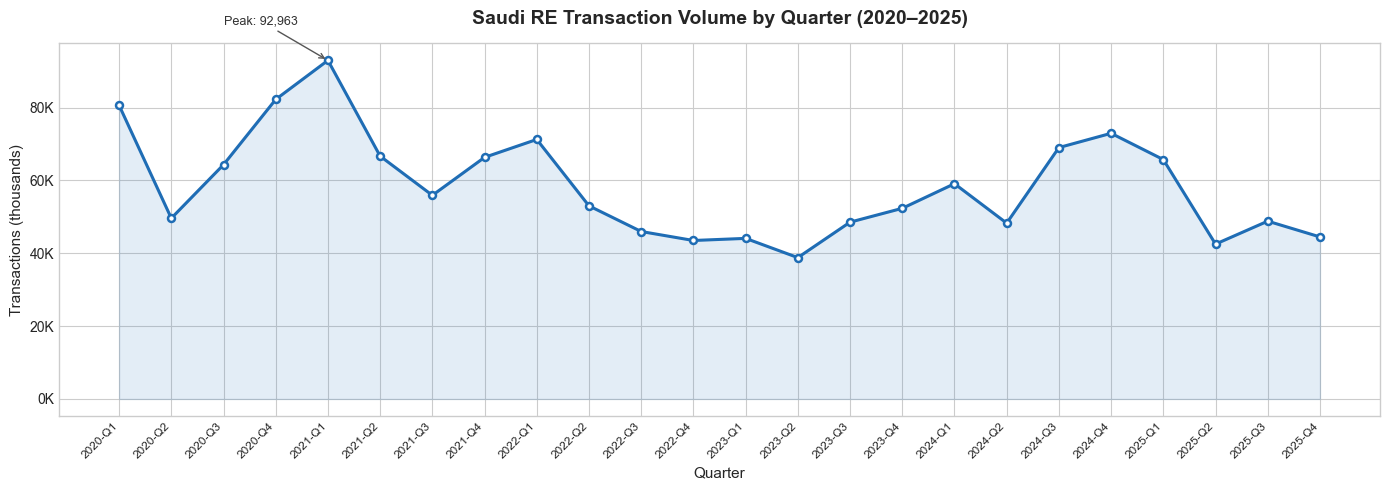

Saved → chart_transaction_volume.png


In [4]:
# ── Chart 1: Quarterly transaction COUNT over time ────────────────────────

vol = (
    df.groupby('year_quarter')
      .size()
      .reindex(yq_order)
      .reset_index(name='count')
)

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(vol['year_quarter'], vol['count'] / 1_000,
        color='#1f6db5', linewidth=2.2, marker='o', markersize=5,
        markerfacecolor='white', markeredgewidth=1.8)

ax.fill_between(vol['year_quarter'], vol['count'] / 1_000,
                alpha=0.12, color='#1f6db5')

ax.set_title('Saudi RE Transaction Volume by Quarter (2020–2025)',
             fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Quarter', fontsize=11)
ax.set_ylabel('Transactions (thousands)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}K'))

# Rotate x-axis labels for readability
ax.set_xticks(range(len(yq_order)))
ax.set_xticklabels(yq_order, rotation=45, ha='right', fontsize=8.5)

# Annotate peak quarter
peak_idx = vol['count'].idxmax()
peak_yq  = vol.loc[peak_idx, 'year_quarter']
peak_val = vol.loc[peak_idx, 'count']
ax.annotate(f"Peak: {peak_val:,}",
            xy=(peak_idx, peak_val / 1_000),
            xytext=(peak_idx - 2, peak_val / 1_000 + 10),
            arrowprops=dict(arrowstyle='->', color='#555'),
            fontsize=9, color='#333')

plt.tight_layout()
out1 = NB_DIR / 'chart_transaction_volume.png'
fig.savefig(out1, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {out1}")


Top 5 regions: ['Riyadh', 'Makkah', 'Eastern', 'Qassim', 'Asir']


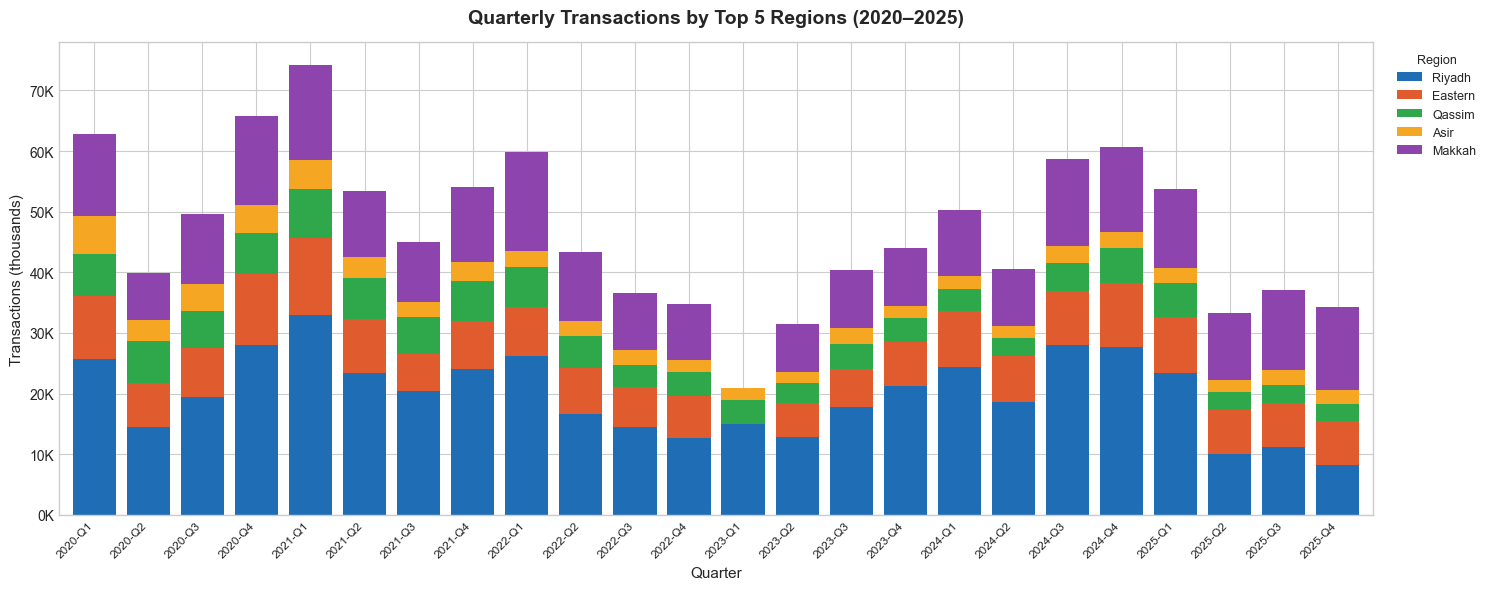

Saved → chart_regional_breakdown.png


In [5]:
# ── Chart 2: Quarterly transactions by top 5 regions (stacked bar) ────────

REGION_EN_MAP = {
    'منطقة الرياض':           'Riyadh',
    'منطقة مكة المكرمه':      'Makkah',
    'منطقة الشرقية':          'Eastern',
    'منطقة القصيم':           'Qassim',
    'منطقة عسير':             'Asir',
    'منطقة المدينة المنوره':  'Madinah',
    'منطقة حائل':             'Hail',
    'منطقة الجوف':            'Al-Jouf',
    'منطقة نجران':            'Najran',
    'منطقة تبوك':             'Tabuk',
    'منطقة جازان':            'Jazan',
    'منطقة الحدود الشمالية':  'Northern Borders',
    'منطقة الباحة':           'Al-Baha',
}

top5_regions = (
    df.groupby('المنطقة')
      .size()
      .nlargest(5)
      .index
      .tolist()
)
print("Top 5 regions:", [REGION_EN_MAP.get(r, r) for r in top5_regions])

pivot = (
    df[df['المنطقة'].isin(top5_regions)]
      .groupby(['year_quarter', 'المنطقة'])
      .size()
      .unstack(fill_value=0)
      .reindex(yq_order)
)
# Rename columns from Arabic to English
pivot.columns = [REGION_EN_MAP.get(c, c) for c in pivot.columns]

PALETTE = ['#1f6db5', '#e05c2f', '#2ea84a', '#f5a623', '#8e44ad']

fig, ax = plt.subplots(figsize=(15, 6))
pivot.div(1_000).plot(kind='bar', stacked=True, ax=ax, color=PALETTE,
                      width=0.8, edgecolor='none')

ax.set_title('Quarterly Transactions by Top 5 Regions (2020–2025)',
             fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Quarter', fontsize=11)
ax.set_ylabel('Transactions (thousands)', fontsize=11)
ax.set_xticklabels(yq_order, rotation=45, ha='right', fontsize=8.5)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}K'))

# Legend outside right
ax.legend(title='Region', bbox_to_anchor=(1.01, 1), loc='upper left',
          fontsize=9, title_fontsize=9)

plt.tight_layout()
out2 = NB_DIR / 'chart_regional_breakdown.png'
fig.savefig(out2, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {out2}")


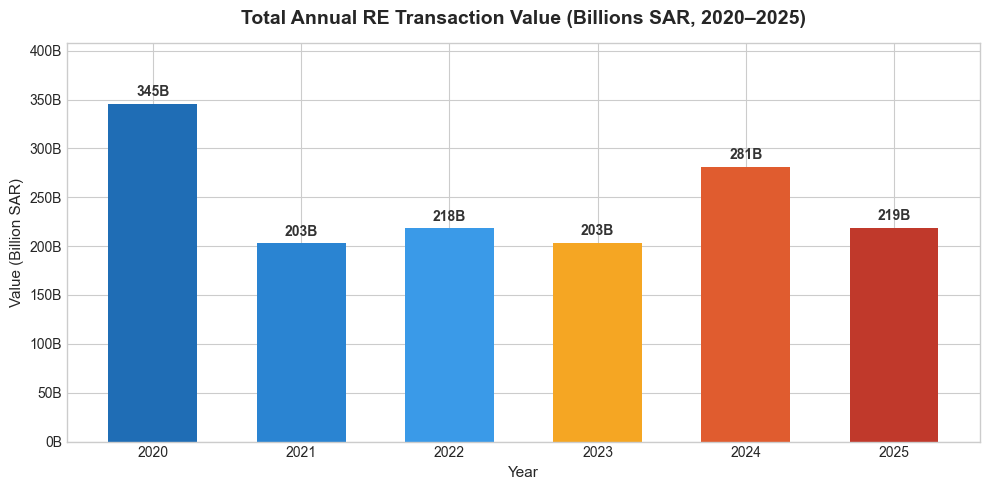

Saved → chart_annual_value.png


In [6]:
# ── Chart 3: Total transaction value by year (bar chart, Billions SAR) ────

annual_value = (
    df.groupby('year')['السعر']
      .sum()
      .reset_index(name='total_sar')
)
annual_value['total_b'] = annual_value['total_sar'] / 1e9

YEAR_COLORS = ['#1f6db5', '#2a84d2', '#3a9ae8', '#f5a623', '#e05c2f', '#c0392b']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(annual_value['year'].astype(str), annual_value['total_b'],
              color=YEAR_COLORS[:len(annual_value)], width=0.6, edgecolor='none')

# Value labels on bars
for bar, val in zip(bars, annual_value['total_b']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 5,
            f'{val:.0f}B',
            ha='center', va='bottom', fontsize=10, fontweight='bold', color='#333')

ax.set_title('Total Annual RE Transaction Value (Billions SAR, 2020–2025)',
             fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Value (Billion SAR)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}B'))
ax.set_ylim(0, annual_value['total_b'].max() * 1.18)

plt.tight_layout()
out3 = NB_DIR / 'chart_annual_value.png'
fig.savefig(out3, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {out3}")


## Key Observations

- **Transaction volume** shows notable growth from 2020 through 2022, driven by post-pandemic demand recovery and Vision 2030 housing initiatives.
- **Riyadh (منطقة الرياض)** consistently leads transaction counts, reflecting its status as the capital and primary economic hub.
- **2023–2024** saw elevated activity across most regions, correlating with mortgage accessibility programs and land development incentives.
- **Total transaction value** has grown substantially year-on-year, with 2024 representing the highest aggregate deal value in the dataset.
- Seasonal patterns are visible — Q2 and Q3 tend to have slightly higher activity than Q1 and Q4.
